In [2]:
import pandas as pd
import numpy as np
from datetime import date,timedelta
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
#import imageio
import matplotlib.font_manager as fm
import math
pd.set_option("display.precision", 8)
from netCDF4 import Dataset
import numpy as np
#from mpl_toolkits.basemap import Basemap
from matplotlib.patches import Polygon
import warnings
from datetime import timedelta as delta

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

#warnings.filterwarnings('ignore')

# REading files

### Particle file

In [3]:
#OP_output= '/home/por07g/Documents/Projects/GBR_modeling/GBR_oceanparcels/GBR_main/out1_new/GBR1_H2p0_Coral_Release_2015-10-29_Polygon_986_Wind_3_percent_displacement_field.nc'
OP_output= '../datasets/outputs/GBR1_H2p0_Coral_Release_2015-10-29_Polygon_1358_Wind_3_percent_displacement_field.nc'
oparcels = xr.open_dataset(OP_output)
lat_part = oparcels['lat']
lon_part = oparcels['lon']


# Select polygon
- I need to update shapely

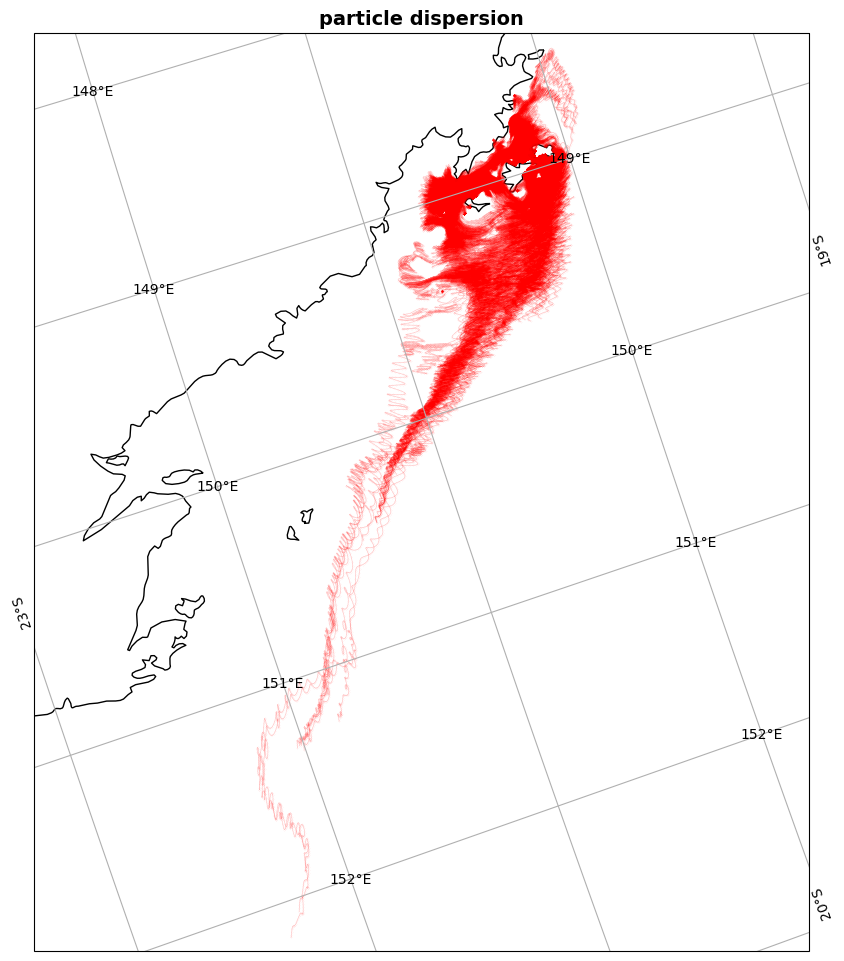

In [4]:
fig = plt.figure(figsize=(10,12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal())

ax.set_extent([lon_part.min()-0.05, lon_part.max()+0.05, lat_part.min()-0.05, lat_part.max()+0.05], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

for prt_i in range(0,500):
    xp, yp = np.meshgrid(lon_part[prt_i, :], lat_part[prt_i,:])
    ax.plot(xp[0,:], yp[:,0], marker='o', color='red', linewidth=0.5, markersize=0.1, alpha=0.2, transform=ccrs.PlateCarree())

plt.title('particle dispersion', fontsize=14, fontweight = 'bold')
#plt.savefig('Figures/Seeding_location.png')
plt.show()

## Test connectivity for this reef

In [58]:
from util_tools import *
### Main Matrix Calculations
#def calc(path, release_start_day, source_reef, num_reefs, data_shape, tc_CoTS, peak_age, phase_age):
release_start_day= '2015-10-29'
source_reef = 1358
num_reefs = 3806
path = '../datasets/outputs/'

data_shape = gpd.read_file('../datasets/shapefiles/gbr1_coral_1m_merged_buffer0p001.shp')

# getting the boundaries of each reefs for
# entired GBR
num_reefs = data_shape.shape[0]
min_lat = []
max_lat = []
for i_polygon in range(0, num_reefs):
    min_lat.append(
        np.nanmin(np.array(data_shape['geometry'][i_polygon].bounds)[[1, 3]]))
    max_lat.append(
        np.nanmax(np.array(data_shape['geometry'][i_polygon].bounds)[[1, 3]]))
data_shape['min_lat'] = min_lat
data_shape['max_lat'] = max_lat




t = time.time()
# Creating empty arrays
connectivity_matrix_sum = np.zeros(num_reefs)
connectivity_matrix_max = np.zeros(num_reefs)
connectivity_variance_sum = np.zeros(num_reefs)
connectivity_variance_max = np.zeros(num_reefs)

file_name = '../datasets/outputs/GBR1_H2p0_Coral_Release_2015-10-29_Polygon_1358_Wind_3_percent_displacement_field.nc'
#_Wind_3_percent_displacement_field
output_nc = xr.open_dataset(file_name)
#print(output_nc.variables)
ntraj = output_nc.dims['traj']

particles = pd.DataFrame({
    'latitudes': output_nc['lat'].values.ravel(),
    'longitudes': output_nc['lon'].values.ravel(),
    'trajectories': output_nc['trajectory'].values.ravel(),
    'age': output_nc['age'].values.ravel() / 86400  # Seconds to days
})
output_nc.close()
## ~~~~~~~~~~~~~~~~~~~~ ##
## ~      Parameters  ~ ##
## ~~~~~~~~~~~~~~~~~~~~ ##
# Parameters used in the decay and competence function
# Decay
Tcp_decay = 2.583
lmbda1 = 0.4
lmbda2 = 0.019
v1 = 2.892
v2 = 1.716
sigma1 = 0
sigma2 = 0

# Competence for corals
tc = 14
Tcp_comp = 69.91245
alpha = 1.295
beta1 = 0.001878001
beta2 = 0.3968972
v = 0.364

## Cleaning and setting boundaries

In [59]:
# Cleaning the nans
particles = particles.dropna()
# remove particles bellow minimum age and maximum age
particles = particles[particles['age'] >= tc]
print('Step_2 Particle age: '+ str(tc))
particle_max_lat = np.nanmax(particles['latitudes'].values)
print('max latitude: ' + str(particle_max_lat))
particle_min_lat = np.nanmin(particles['latitudes'].values)
print('min latitude: ' + str(particle_min_lat))
print('\nStep_3 Lat and lon Readed')

# making boolean series
upper_bound = data_shape['min_lat'] <= particle_max_lat
mmax = upper_bound.to_numpy()
print('mmax: ' + str(mmax))
inf_bound = data_shape['max_lat'] >= particle_min_lat
minf = inf_bound.to_numpy()
boundary_reefs = np.where(np.multiply(minf, mmax))[0]
print(boundary_reefs)
print('Step_4 entering the main loop')

Step_2 Particle age: 14
max latitude: -19.888914
min latitude: -22.339048

Step_3 Lat and lon Readed
mmax: [False False False ...  True  True  True]
[  11   12   13 ... 3769 3778 3790]
Step_4 entering the main loop


## searching particles inside polygons

In [60]:

## I will create an object call all_index to store the index of the reefs
## that have particles in it
all_index = []
for sink_reef in boundary_reefs:
    # given the sink_reef position get the FID from the shapefile
    reef_index = data_shape['FID'][sink_reef]
    all_index.append(reef_index)
    polygon = np.array(list(data_shape['geometry'][sink_reef].exterior.coords))
    if (particles.size == 0):
        break  # breaking the loop if not more particles
    # Are these points inside the polygon?
    p = points_in_polygon(
        particles['longitudes'].values,
        particles['latitudes'].values,
        data_shape.min_lat[sink_reef],
        data_shape.max_lat[sink_reef],
        polygon,
    )
    m = np.where(p)[0]
    if(len(m > 0)):
        settled_age  = particles['age'].iloc[m].values
        settled_traj = particles['trajectories'].iloc[m].values
        decay = piecewise_decay(settled_age, Tcp_decay, lmbda1, lmbda2, v1, v2, sigma1, sigma2)
        competence = piecewise_competence(settled_age, tc, Tcp_comp, alpha, beta1, beta2, v)
        connect = pd.DataFrame({'connect':np.array(decay) * np.array(competence), 'traj':settled_traj})
        connect_sum = (connect.groupby('traj')['connect'].sum()/ntraj).to_numpy()
        connect_max = (connect.groupby('traj')['connect'].max()/ntraj).to_numpy()
        ## Average connectivity through all the particles in that reef
        connectivity_matrix_max[reef_index] = connect_max.mean()
        connectivity_matrix_sum[reef_index] = connect_sum.mean()
        ## Variance
        connectivity_variance_max[reef_index] = connect_max.var()
        connectivity_variance_sum[reef_index] = connect_sum.var()
        particles.drop(index = particles.iloc[m].index, inplace=True)

    #        print('Done', source_reef, int(time.time() - t + 0.5), flush=True)


total sum Connectivity matrix max
0.0794738025215735
total sum Connectivity matrix no inded
0.0794738025215735


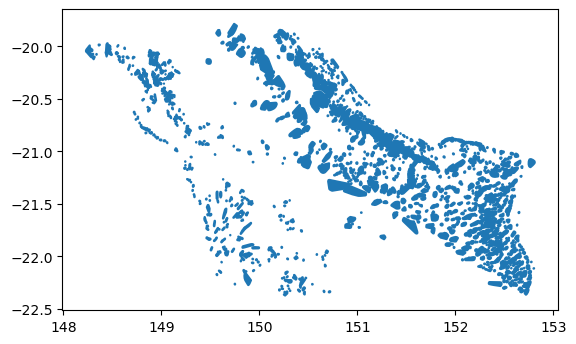

In [67]:
#plot all the reefs that the FID value is equal to all_index
data_shape[data_shape['FID'].isin(all_index)].plot()

# I want to check if the all_idex are the index of the_connectivity matrix_max that have values
# different from zero
print('total sum Connectivity matrix max')
print(connectivity_matrix_max[all_index].sum())
print('total sum Connectivity matrix no inded')
print(connectivity_matrix_max.sum())



In [63]:
# Convert the connectivity matrix to a pandas DataFrame
connectivity_matrix_df = pd.DataFrame(connectivity_matrix_max, columns=['connectivity'])

# Join the sorted DataFrame to the shapefile
reefs = reefs.join(connectivity_matrix_df)

print(reefs)


       FID  success    distance  was_moved       area  \
0      787      0.0  0.00232783        1.0     104274   
1      802      0.0  0.00255176        1.0      55711   
2      818      0.0  0.00048810        1.0      85109   
3      820      0.0  0.00174946        1.0      65857   
4      822      0.0  0.00441735        1.0     555012   
...    ...      ...         ...        ...        ...   
3801  3801      1.0  0.00000000        NaN     558139   
3802  3802      1.0  0.00000000        NaN    4489489   
3803  3803      1.0  0.00000000        NaN    6125214   
3804  3804      1.0  0.00000000        NaN   18133473   
3805  3805      1.0  0.00000000        NaN  110295567   

                                               geometry  connectivity  
0     POLYGON ((145.93069 -16.85301, 145.93200 -16.8...           0.0  
1     POLYGON ((145.93624 -16.86086, 145.93746 -16.8...           0.0  
2     POLYGON ((145.93915 -16.86394, 145.93970 -16.8...           0.0  
3     POLYGON ((145.94985 -

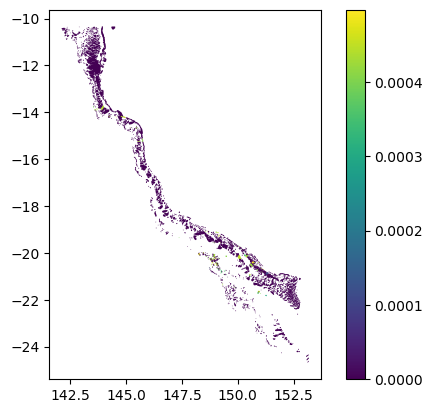

In [64]:
# Plot the shapefile with different colors based on the 'connectivity' values
fig, ax = plt.subplots(1, 1)
reefs.plot(column='connectivity', ax=ax, legend=True)

# Show the plot
plt.show()

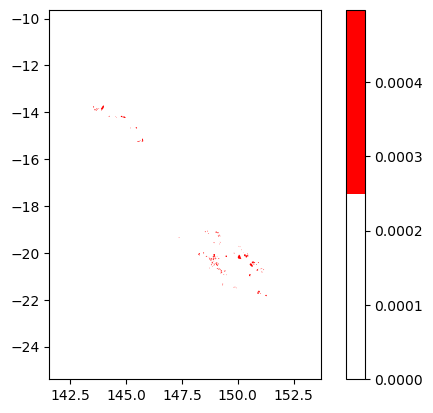

In [65]:
import matplotlib.colors as colors

# Create a custom color map
cmap = colors.ListedColormap(['white', 'red'])

# Define the normalization: from 0 (white) to max value (red)
norm = colors.Normalize(vmin=0, vmax=reefs['connectivity'].max())

# Plot the shapefile with different colors based on the 'connectivity' values
fig, ax = plt.subplots(1, 1)
reefs.plot(column='connectivity', ax=ax, cmap=cmap, norm=norm, legend=True)

# Show the plot
plt.show()